# 04: Partially Linear IV PLIV

This lesson is a full tutorial on `DoubleMLPLIV`, the partially linear instrumental-variable model for a continuous treatment.

The previous notebook handled a continuous treatment under observed-control adjustment. Here we make the problem harder: even after controlling for observed covariates, the treatment is still endogenous because an unobserved factor affects both treatment and outcome. A valid instrument can recover the treatment effect by using treatment variation induced by the instrument.

The lesson is intentionally theory-heavy because IV designs are easy to misuse. The package can estimate an IV model. Instrument validity still comes from the design argument.

## Learning Goals

By the end, you should be able to:

- Explain why observed-control adjustment can fail when treatment is endogenous.
- State the PLIV model and the role of the instrument.
- Distinguish instrument relevance, exclusion, and conditional independence.
- Understand the `DoubleMLPLIV` nuisance roles: `ml_l`, `ml_m`, and `ml_r`.
- Manually compute the residualized IV estimand using cross-fitted nuisance predictions.
- Fit `DoubleMLPLIV` with linear and nonlinear nuisance learners.
- Diagnose first-stage strength and residual treatment variation.
- Explain why weak or invalid instruments can make IV estimates unstable or biased.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Partially Linear IV PLIV**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment shows a setting where treatment choice is endogenous and identification must come from a source of quasi-random variation. The experiment uses an instrument to separate treatment variation from unobserved outcome shocks. First-stage strength and exclusion logic matter as much as the estimate.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

The partially linear IV model introduces an instrument $Z$ for treatment $D$,

$$
Y=\theta_0D+g_0(X)+\varepsilon, \qquad D=r_0(Z,X)+u.
$$

The orthogonalized IV moment can be read as

$$
\mathbb{E}\left[\{Z-\mathbb{E}(Z\mid X)\}\{Y-\theta_0D-g_0(X)\}\right]=0.
$$

The diagnostics should therefore focus on instrument relevance, exclusion plausibility, and stability of the IV estimate.


## Why We Need IV

Observed-control methods such as PLR assume that, after conditioning on `X`, the remaining treatment variation is usable for causal estimation. That assumption fails when there is an unobserved variable `U` that affects both the treatment `D` and the outcome `Y`.

An instrument `Z` is a variable that shifts treatment but does not directly shift the outcome except through treatment. If the instrument is valid, it can isolate a source of treatment variation that is not contaminated by the unobserved confounder.

The IV logic is powerful, but fragile. A weak instrument can create noisy estimates. An invalid instrument can create precise estimates of the wrong quantity.




## Tutorial Workflow

### The PLIV Model

The partially linear IV model can be written as:

$$
Y - D\theta_0 = g_0(X) + \zeta, \quad E[\zeta \mid Z, X] = 0
$$

and

$$
Z = m_0(X) + V, \quad E[V \mid X] = 0.
$$

For the partialling-out score used here, DoubleML also learns:

$$
r_0(X) = E[D \mid X].
$$

The target parameter is `theta_0`, the causal effect of the continuous treatment on the outcome under the IV design assumptions.

The key residualized moment is:

$$
E[(Z - m_0(X))\{Y - l_0(X) - \theta_0(D - r_0(X))\}] = 0,
$$

where `l_0(X) = E[Y | X]`, `m_0(X) = E[Z | X]`, and `r_0(X) = E[D | X]`.

### The Three Main IV Assumptions

A credible IV design usually needs at least these conditions:

- Relevance: the instrument changes the treatment after adjusting for controls.
- Exclusion: the instrument affects the outcome only through the treatment.
- Conditional independence: after adjusting for controls, the instrument is not related to unobserved outcome shocks.

Only relevance can be directly screened in the data through first-stage diagnostics. Exclusion and conditional independence require design arguments, domain knowledge, institutional details, or randomized encouragement.

### Runtime Note

This lesson fits several cross-fitted nuisance models and a repeated-split check. On a typical laptop, the full notebook should take roughly two to four minutes.

The weak-instrument and invalid-instrument sections use fast oracle-style residual calculations rather than repeatedly fitting large machine-learning models. That keeps the cautionary simulations readable and quick.

#### Setup

The code below prepares the notebook environment. It creates output folders, makes matplotlib cache writes local to the tutorial folder, imports the scientific Python stack, and records package versions.

The path logic supports running the notebook either from the repository root or from the tutorial folder.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings

NOTEBOOK_PREFIX = "04"
RANDOM_STATE = 2026

CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "doubleml":
    REPO_ROOT = CURRENT_DIR.parents[2]
elif (CURRENT_DIR / "notebooks" / "tutorials" / "doubleml").exists():
    REPO_ROOT = CURRENT_DIR
else:
    REPO_ROOT = CURRENT_DIR

OUTPUT_DIR = REPO_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLPLIV

warnings.filterwarnings("ignore", category=ConvergenceWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

package_versions = pd.DataFrame(
    [
        {"package": "doubleml", "version": dml.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "seaborn", "version": sns.__version__},
        {"package": "statsmodels", "version": sm.__version__},
    ]
)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,doubleml,0.11.2
1,numpy,2.4.4
2,pandas,3.0.2
3,seaborn,0.13.2
4,statsmodels,0.14.6


The package table is saved with the notebook outputs. IV estimates can change slightly with learner implementations, random splits, and numerical defaults, so version tracking is part of the reproducibility story.

#### Helper Functions

The next cell defines utilities for saving tables, computing OLS summaries, residualizing variables, computing residualized IV estimates, and extracting DoubleML diagnostics.

The residualized IV function is especially important because it makes the PLIV score concrete: estimate the slope using the covariance between residualized instrument and residualized outcome divided by the covariance between residualized instrument and residualized treatment.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, name):
    """
    Idea: Save a result table to the notebook table directory and return the same DataFrame for display.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    name : str
        Short name used for the saved artifact or scenario label.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / f"{NOTEBOOK_PREFIX}_{name}.csv"
    df.to_csv(path, index=False)
    return df


def rmse(y_true, y_pred):
    """
    Idea: Compute root mean squared error between an oracle target and an estimated or predicted value.
    
    Parameters
    ----------
    y_true : array-like
        Reference outcome, oracle value, or known target used for evaluation.
    y_pred : array-like
        Predicted outcome or estimated value being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def ols_treatment_summary(y, X, treatment_col, label):
    """
    Idea: Assemble a summary of the OLS treatment summary with the quantities needed for interpretation.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    X : pd.DataFrame or np.ndarray
        Feature matrix containing pre-treatment covariates or effect modifiers.
    treatment_col : str
        Name of the treatment or intervention column.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    dict[str, float]
        Regression treatment-slope summary row with estimate and uncertainty fields.
    """
    X_design = sm.add_constant(X, has_constant="add")
    fit = sm.OLS(y, X_design).fit(cov_type="HC1")
    row = fit.summary2().tables[1].loc[treatment_col]
    return {
        "estimator": label,
        "theta_hat": float(row["Coef."]),
        "std_error": float(row["Std.Err."]),
        "ci_95_lower": float(row["[0.025"]),
        "ci_95_upper": float(row["0.975]"]),
        "p_value": float(row["P>|z|"]),
        "r_squared": float(fit.rsquared),
    }


def residualize_with_linear_model(values, controls):
    """
    Idea: Fit a linear adjustment model and return residuals for the next-stage causal calculation.
    
    Parameters
    ----------
    values : object
        Numeric values being transformed, summarized, or plotted.
    controls : list[str] or array-like
        Covariates used to adjust, residualize, or condition the target.
    
    Returns
    -------
    np.ndarray
        Residual vector from a fitted linear adjustment model.
    """
    model = LinearRegression()
    fitted = model.fit(controls, values).predict(controls)
    return np.asarray(values) - fitted


def residual_iv_summary(y_resid, d_resid, z_resid, label):
    """
    Idea: Assemble a summary of the residual IV summary with the quantities needed for interpretation.
    
    Parameters
    ----------
    y_resid : object
        Outcome residual after adjustment for controls.
    d_resid : object
        Treatment residual after adjustment for controls.
    z_resid : object
        Instrument residual after adjustment for controls.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    dict[str, float]
        Residualized IV summary row with estimate, interval, and moment denominator.
    """
    y_resid = np.asarray(y_resid)
    d_resid = np.asarray(d_resid)
    z_resid = np.asarray(z_resid)
    n_obs = len(y_resid)
    denominator = float(np.mean(z_resid * d_resid))
    theta_hat = float(np.mean(z_resid * y_resid) / denominator)
    psi = z_resid * (y_resid - theta_hat * d_resid)
    std_error = float(np.sqrt(np.mean(psi ** 2) / (denominator ** 2 * n_obs)))
    return {
        "estimator": label,
        "theta_hat": theta_hat,
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "moment_denominator": denominator,
    }


def first_stage_summary(d_resid, z_resid, label):
    """
    Idea: Summarize the instrument-to-treatment relationship that supports the IV design.
    
    Parameters
    ----------
    d_resid : object
        Treatment residual after adjustment for controls.
    z_resid : object
        Instrument residual after adjustment for controls.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    dict[str, float]
        First-stage diagnostic row with slope, R-squared, F statistic, and residual correlation.
    """
    X_design = sm.add_constant(pd.DataFrame({"z_resid": z_resid}), has_constant="add")
    fit = sm.OLS(d_resid, X_design).fit()
    return {
        "diagnostic": label,
        "first_stage_slope": float(fit.params["z_resid"]),
        "first_stage_r2": float(fit.rsquared),
        "first_stage_f_stat": float(fit.fvalue),
        "residual_corr_z_d": float(np.corrcoef(z_resid, d_resid)[0, 1]),
    }


def prediction_vector(doubleml_model, learner_key):
    """
    Idea: Return predictions from a learner as a flat numeric vector with shape compatible with later diagnostics.
    
    Parameters
    ----------
    doubleml_model : object
        Model object used for `doubleml` fitting, prediction, or comparison.
    learner_key : object
        Dictionary key identifying which learner configuration is being evaluated.
    
    Returns
    -------
    np.ndarray
        One-dimensional prediction array aligned with the evaluation rows.
    """
    arr = np.asarray(doubleml_model.predictions[learner_key])
    if arr.ndim != 3:
        raise ValueError(f"Expected a 3D prediction array, got shape {arr.shape}")
    return arr[:, 0, 0]


def learner_loss_table(doubleml_model, model_label):
    """
    Idea: Assemble a DataFrame for the learner loss table so the result can be displayed and saved consistently.
    
    Parameters
    ----------
    doubleml_model : object
        Model object used for `doubleml` fitting, prediction, or comparison.
    model_label : str
        Display label for `model`.
    
    Returns
    -------
    pd.DataFrame
        Out-of-fold nuisance prediction loss table by learner and nuisance role.
    """
    losses = doubleml_model.evaluate_learners()
    rows = []
    for learner_name, values in losses.items():
        arr = np.asarray(values)
        rows.append(
            {
                "model": model_label,
                "learner": learner_name,
                "mean_rmse": float(np.mean(arr)),
                "min_rmse": float(np.min(arr)),
                "max_rmse": float(np.max(arr)),
            }
        )
    return pd.DataFrame(rows)


The manual IV helper uses the same core moment that the PLIV partialling-out score uses. This makes the DoubleML output easier to trust because we can reproduce the core calculation ourselves.

#### Draw the IV Design

The figure below shows the teaching design.

`X` affects the instrument, treatment, and outcome. `Z` affects `D`. `D` affects `Y`. The hidden factor `U` affects both `D` and `Y`, creating endogeneity that ordinary observed-control adjustment cannot remove.

The instrument is useful only if the dashed hidden path does not also connect to `Z` after conditioning on `X`, and if `Z` has no direct path to `Y` except through `D`.

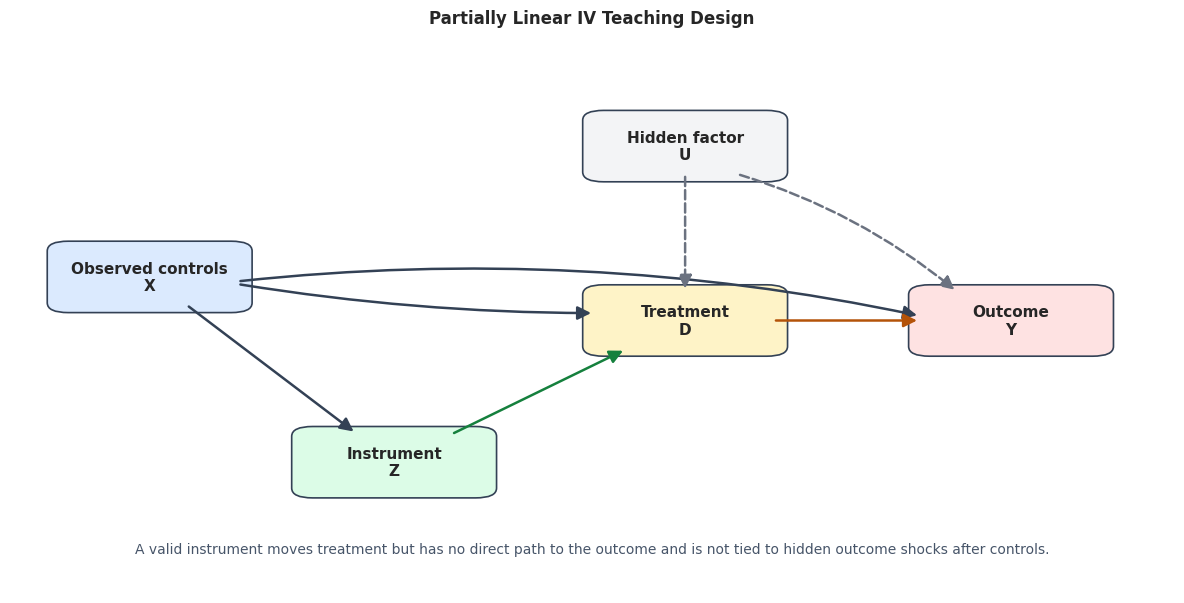

In [3]:
# Define reusable helpers for the Draw The IV Design section.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

nodes = {
    "X": {"xy": (0.12, 0.58), "label": "Observed controls\nX", "color": "#dbeafe"},
    "Z": {"xy": (0.33, 0.24), "label": "Instrument\nZ", "color": "#dcfce7"},
    "D": {"xy": (0.58, 0.50), "label": "Treatment\nD", "color": "#fef3c7"},
    "Y": {"xy": (0.86, 0.50), "label": "Outcome\nY", "color": "#fee2e2"},
    "U": {"xy": (0.58, 0.82), "label": "Hidden factor\nU", "color": "#f3f4f6"},
}

edge_specs = [
    ("X", "Z", "#334155", "solid", 0.00),
    ("X", "D", "#334155", "solid", 0.04),
    ("X", "Y", "#334155", "solid", -0.08),
    ("Z", "D", "#15803d", "solid", 0.00),
    ("D", "Y", "#b45309", "solid", 0.00),
    ("U", "D", "#6b7280", "dashed", 0.00),
    ("U", "Y", "#6b7280", "dashed", -0.10),
]

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.set_axis_off()
box_w, box_h = 0.14, 0.095

def edge_endpoint(source_xy, target_xy, from_source=True):
    """
    Return a point just outside the source or target box boundary.
    
    Parameters
    ----------
    source_xy : tuple[float, float]
        Starting coordinate for a drawn edge.
    target_xy : tuple[float, float]
        Ending coordinate for a drawn edge.
    from_source : bool
        Whether to compute the boundary point from the source side of the edge.
    
    Returns
    -------
    tuple[float, float]
        Adjusted endpoint coordinate for a directed or partially directed graph edge.
    """
    x0, y0 = source_xy
    x1, y1 = target_xy
    dx, dy = x1 - x0, y1 - y0
    scale = 1.0 / max(abs(dx) / (box_w / 2), abs(dy) / (box_h / 2))
    if from_source:
        return (x0 + dx * scale * 1.08, y0 + dy * scale * 1.08)
    return (x1 - dx * scale * 1.12, y1 - dy * scale * 1.12)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

for start, end, color, style, rad in edge_specs:
    start_xy = edge_endpoint(nodes[start]["xy"], nodes[end]["xy"], from_source=True)
    end_xy = edge_endpoint(nodes[start]["xy"], nodes[end]["xy"], from_source=False)
    arrow = FancyArrowPatch(
        start_xy,
        end_xy,
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=1.8,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=5,
    )
    ax.add_patch(arrow)

ax.text(
    0.50,
    0.08,
    "A valid instrument moves treatment but has no direct path to the outcome and is not tied to hidden outcome shocks after controls.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Partially Linear IV Teaching Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pliv_design_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The diagram is the causal story the estimator depends on. The analysis can screen relevance and stability, but the exclusion and independence arrows require an argument outside the fitted model.

#### Create an Example Dataset with Endogeneity

We now simulate a dataset where treatment is endogenous.

The hidden variable `latent_demand_shock` affects both treatment and outcome. It is not included in the observed controls. This means PLR-style adjustment with `X` alone will remain biased.

The instrument `encouragement_score` affects treatment and is generated so that its residual variation is not tied to the hidden demand shock. That makes it valid in this synthetic setup.

In [4]:
# Save the artifacts produced by the Create An Example Dataset With Endogeneity section.
rng = np.random.default_rng(RANDOM_STATE)
N_OBS = 2_500
TRUE_THETA = 2.00
FIRST_STAGE_STRENGTH = 0.85
HIDDEN_CONFOUNDING_STRENGTH = 1.15
HIDDEN_OUTCOME_STRENGTH = 1.25

feature_cols = [
    "engagement_score",
    "need_intensity",
    "content_fit",
    "recent_activity",
    "price_sensitivity",
    "tenure_signal",
    "novelty_appetite",
    "seasonality_signal",
]

X_raw = pd.DataFrame(rng.normal(size=(N_OBS, len(feature_cols))), columns=feature_cols)

true_instrument_nuisance = (
    0.80 * np.sin(X_raw["engagement_score"])
    + 0.45 * X_raw["need_intensity"]
    - 0.35 * X_raw["price_sensitivity"]
    + 0.25 * X_raw["seasonality_signal"]
)

true_treatment_x_signal = (
    0.55 * X_raw["content_fit"]
    + 0.40 * np.sin(X_raw["recent_activity"])
    - 0.30 * X_raw["tenure_signal"]
    + 0.25 * X_raw["need_intensity"] ** 2
)

true_structural_g = (
    0.90 * np.sin(X_raw["engagement_score"] * X_raw["content_fit"])
    + 0.65 * X_raw["novelty_appetite"] ** 2
    - 0.35 * X_raw["seasonality_signal"]
    + 0.35 * X_raw["recent_activity"]
)

latent_demand_shock = rng.normal(loc=0.0, scale=1.0, size=N_OBS)
instrument_noise = rng.normal(loc=0.0, scale=1.0, size=N_OBS)
treatment_noise = rng.normal(loc=0.0, scale=1.0, size=N_OBS)
outcome_noise = rng.normal(loc=0.0, scale=1.0, size=N_OBS)

encouragement_score = true_instrument_nuisance + instrument_noise
true_treatment_nuisance = FIRST_STAGE_STRENGTH * true_instrument_nuisance + true_treatment_x_signal
exposure_intensity = (
    FIRST_STAGE_STRENGTH * encouragement_score
    + true_treatment_x_signal
    + HIDDEN_CONFOUNDING_STRENGTH * latent_demand_shock
    + treatment_noise
)

true_outcome_nuisance = TRUE_THETA * true_treatment_nuisance + true_structural_g
weekly_value = (
    TRUE_THETA * exposure_intensity
    + true_structural_g
    + HIDDEN_OUTCOME_STRENGTH * latent_demand_shock
    + outcome_noise
)

pliv_df = X_raw.assign(
    encouragement_score=encouragement_score,
    exposure_intensity=exposure_intensity,
    weekly_value=weekly_value,
    true_instrument_nuisance=true_instrument_nuisance,
    true_treatment_nuisance=true_treatment_nuisance,
    true_outcome_nuisance=true_outcome_nuisance,
    true_structural_g=true_structural_g,
    latent_demand_shock=latent_demand_shock,
    instrument_noise=instrument_noise,
    treatment_noise=treatment_noise,
    outcome_noise=outcome_noise,
)

pliv_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_pliv_data.csv", index=False)
print(f"Saved synthetic PLIV data with shape {pliv_df.shape}")
display(pliv_df.head())


Saved synthetic PLIV data with shape (2500, 19)


,engagement_score,need_intensity,content_fit,recent_activity,price_sensitivity,tenure_signal,novelty_appetite,seasonality_signal,encouragement_score,exposure_intensity,weekly_value,true_instrument_nuisance,true_treatment_nuisance,true_outcome_nuisance,true_structural_g,latent_demand_shock,instrument_noise,treatment_noise,outcome_noise
0,-0.793122,0.240571,-1.896326,1.395772,0.638295,-0.292047,-0.311949,0.303835,-1.155305,0.566060,2.576062,-0.609225,-1.064849,-0.786274,1.343425,0.768580,-0.546080,1.211211,-0.860208
1,-0.267660,-0.225909,0.720068,0.514705,-0.064128,-0.085477,0.160916,-0.614018,-1.264957,-1.345176,-4.282584,-0.444299,0.253696,0.746888,0.239496,-0.948917,-0.820658,0.189942,-0.645581
2,-0.403750,0.548260,-0.130483,-1.374426,-0.477279,0.656622,-0.232283,-0.148733,0.740472,-1.881422,-4.056820,0.062286,-0.532974,-1.412478,-0.346529,-0.253207,0.678186,-1.633718,0.369063
3,0.641837,1.824610,-0.713189,1.348207,-1.230013,0.174978,-1.169530,1.351458,2.966237,4.111388,11.641070,2.068378,2.535806,5.561806,0.490193,1.285489,0.897859,-0.665911,1.321239
4,0.833923,1.137717,-0.885533,0.684555,-0.519013,-0.457385,0.506537,0.876718,1.694021,2.640015,6.837626,1.505265,1.506179,2.506039,-0.506319,0.669900,0.188756,0.203009,1.226540


The hidden columns are included only because this is a teaching simulation. In an applied dataset, the hidden demand shock would be exactly the problem: it would affect treatment and outcome, but we would not observe it.

#### Field Dictionary

This table documents the role of every important column. The `ml_m` and `ml_r` distinction is worth repeating: in PLIV, `ml_m` predicts the instrument and `ml_r` predicts the treatment.

In [5]:
field_dictionary = pd.DataFrame(
    [
        {"column": "weekly_value", "role": "outcome", "description": "Observed outcome Y."},
        {"column": "exposure_intensity", "role": "continuous treatment", "description": "Observed endogenous treatment D."},
        {"column": "encouragement_score", "role": "instrument", "description": "Instrument Z that shifts treatment in the synthetic design."},
        *[
            {"column": col, "role": "control", "description": "Observed pre-treatment control X."}
            for col in feature_cols
        ],
        {"column": "true_instrument_nuisance", "role": "hidden teaching column", "description": "True m0(X) = E[Z | X]."},
        {"column": "true_treatment_nuisance", "role": "hidden teaching column", "description": "True r0(X) = E[D | X]."},
        {"column": "true_outcome_nuisance", "role": "hidden teaching column", "description": "True l0(X) = E[Y | X]."},
        {"column": "true_structural_g", "role": "hidden teaching column", "description": "Structural outcome component g0(X)."},
        {"column": "latent_demand_shock", "role": "hidden confounder", "description": "Unobserved variable that affects D and Y."},
        {"column": "instrument_noise", "role": "hidden teaching column", "description": "Residual instrument variation V."},
        {"column": "treatment_noise", "role": "hidden teaching column", "description": "Treatment disturbance."},
        {"column": "outcome_noise", "role": "hidden teaching column", "description": "Outcome disturbance."},
    ]
)
save_table(field_dictionary, "field_dictionary")
display(field_dictionary)


,column,role,description
0,weekly_value,outcome,Observed outcome Y.
1,exposure_intensity,continuous treatment,Observed endogenous treatment D.
2,encouragement_score,instrument,Instrument Z that shifts treatment in the synthetic design.
3,engagement_score,control,Observed pre-treatment control X.
4,need_intensity,control,Observed pre-treatment control X.
5,content_fit,control,Observed pre-treatment control X.
6,recent_activity,control,Observed pre-treatment control X.
7,price_sensitivity,control,Observed pre-treatment control X.
8,tenure_signal,control,Observed pre-treatment control X.
9,novelty_appetite,control,Observed pre-treatment control X.


The instrument is intentionally kept out of the control set. In DoubleML, it belongs in `z_cols`, not in `x_cols`. Mixing these roles would change the represented design.




## Diagnostics and Interpretation

### Basic Data Audit

Before modeling, we check missingness, scale, and variation for outcome, treatment, instrument, and controls.

For IV work, low instrument variation or an instrument with many missing values is an immediate concern. A model can still run, but the design would be weak.

In [6]:
audit_cols = ["weekly_value", "exposure_intensity", "encouragement_score"] + feature_cols

data_audit = pd.DataFrame(
    [
        {
            "column": column,
            "missing_rate": float(pliv_df[column].isna().mean()),
            "mean": float(pliv_df[column].mean()),
            "std": float(pliv_df[column].std()),
            "min": float(pliv_df[column].min()),
            "p05": float(pliv_df[column].quantile(0.05)),
            "median": float(pliv_df[column].median()),
            "p95": float(pliv_df[column].quantile(0.95)),
            "max": float(pliv_df[column].max()),
            "n_unique": int(pliv_df[column].nunique()),
        }
        for column in audit_cols
    ]
)
save_table(data_audit, "data_audit")
display(data_audit)

key_correlations = pliv_df[["weekly_value", "exposure_intensity", "encouragement_score", "latent_demand_shock"]].corr()
save_table(key_correlations.reset_index().rename(columns={"index": "column"}), "key_correlation_matrix")
display(key_correlations)


,column,missing_rate,mean,std,min,p05,median,p95,max,n_unique
0,weekly_value,0.0,1.155906,5.014931,-15.614492,-6.787211,1.149346,9.470862,20.526080,2500
1,exposure_intensity,0.0,0.276030,2.026333,-6.580364,-2.975172,0.259740,3.666418,8.468529,2500
2,encouragement_score,0.0,-0.004725,1.295172,-4.729370,-2.143769,0.016818,2.041244,4.782439,2500
3,engagement_score,0.0,-0.012303,1.008945,-3.659392,-1.700731,-0.006657,1.577062,3.207341,2500
4,need_intensity,0.0,-0.013648,1.012457,-3.124263,-1.700966,-0.017278,1.699801,3.150908,2500
5,content_fit,0.0,0.014915,0.984762,-3.987716,-1.583524,0.029017,1.588052,3.600337,2500
6,recent_activity,0.0,-0.001764,1.003068,-3.573864,-1.606398,0.013650,1.666772,3.653308,2500
7,price_sensitivity,0.0,-0.001416,1.003348,-3.747414,-1.677467,0.025324,1.594293,3.417551,2500
8,tenure_signal,0.0,0.029320,1.028519,-3.586747,-1.677900,0.051146,1.706999,3.667511,2500
9,novelty_appetite,0.0,-0.010284,0.982590,-2.919905,-1.630710,-0.017082,1.624636,3.163086,2500


,weekly_value,exposure_intensity,encouragement_score,latent_demand_shock
weekly_value,1.000000,0.934924,0.404990,0.708042
exposure_intensity,0.934924,1.000000,0.529097,0.573703
encouragement_score,0.404990,0.529097,1.000000,0.015989
latent_demand_shock,0.708042,0.573703,0.015989,1.000000


The hidden demand shock is correlated with treatment and outcome, which creates endogeneity. The instrument is correlated with treatment, which supports relevance in this synthetic setup.



#### Visualize Endogeneity and Relevance

The next figure shows two important relationships.

The left panel shows that the hidden demand shock affects both treatment and outcome. The right panel shows that the instrument moves treatment.

In real data, the left panel is unavailable because the confounder is unobserved. The point of IV is to handle precisely that situation, provided the instrument is credible.

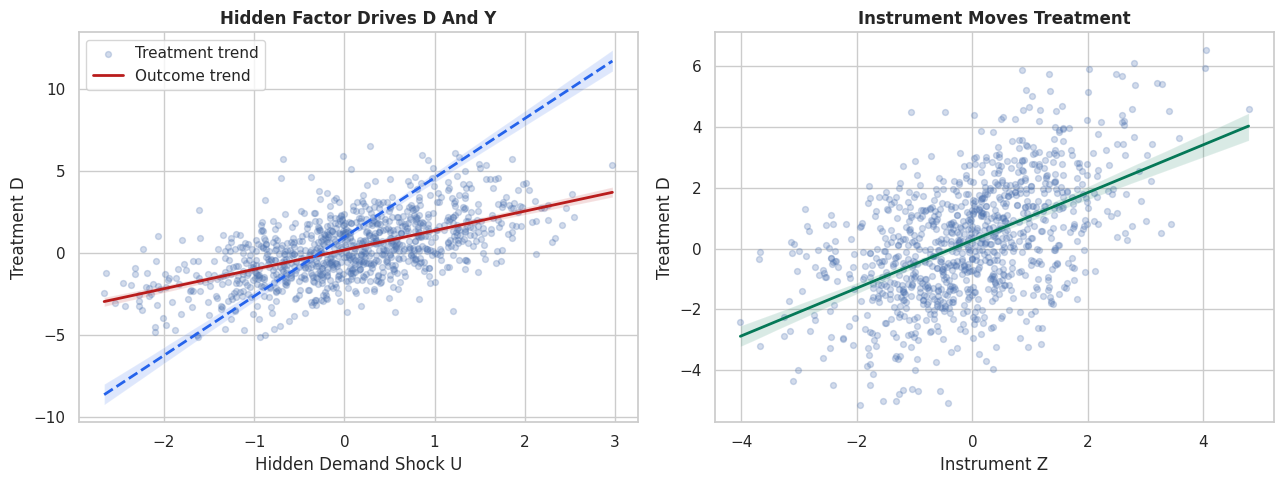

In [7]:
# Build and label the diagnostic visualization for the Visualize Endogeneity And Relevance section.
plot_sample = pliv_df.sample(1_000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(
    data=plot_sample,
    x="latent_demand_shock",
    y="exposure_intensity",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#b91c1c", "linewidth": 2},
    ax=axes[0],
)
sns.regplot(
    data=plot_sample,
    x="latent_demand_shock",
    y="weekly_value",
    scatter=False,
    line_kws={"color": "#2563eb", "linewidth": 2, "linestyle": "--", "label": "Outcome trend"},
    ax=axes[0],
)
axes[0].set_title("Hidden Factor Drives D And Y")
axes[0].set_xlabel("Hidden Demand Shock U")
axes[0].set_ylabel("Treatment D")
axes[0].legend(["Treatment trend", "Outcome trend"])

sns.regplot(
    data=plot_sample,
    x="encouragement_score",
    y="exposure_intensity",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#047857", "linewidth": 2},
    ax=axes[1],
)
axes[1].set_title("Instrument Moves Treatment")
axes[1].set_xlabel("Instrument Z")
axes[1].set_ylabel("Treatment D")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_endogeneity_and_relevance.png", dpi=160, bbox_inches="tight")
plt.show()


This is the central tension: treatment is confounded by an unobserved factor, but the instrument creates an additional source of treatment variation.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




### Design Correlation Matrix

The correlation matrix serves a different role than a causal proof. It helps us inspect the data-generating structure.

The hidden teaching columns are included here only so the simulation is transparent. In real data, we would use observed variables and separate design evidence for the unobserved threats.

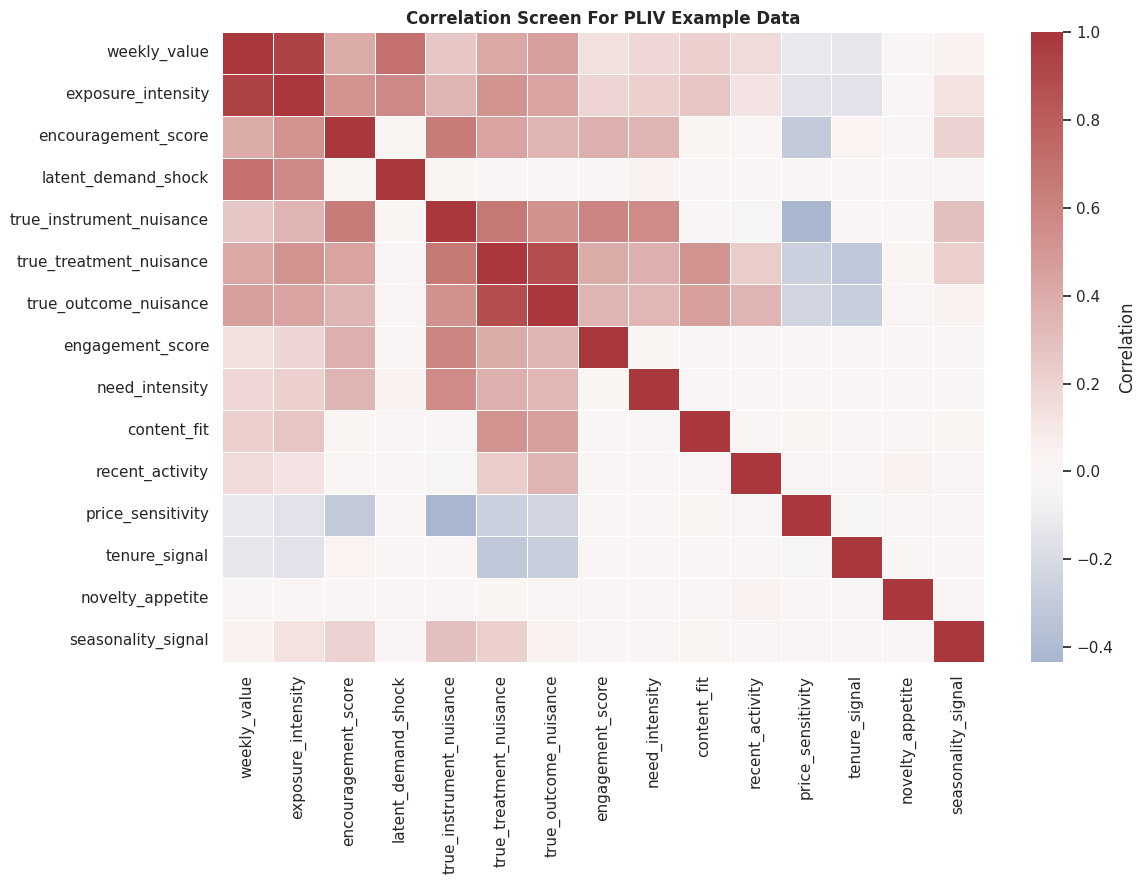

In [8]:
# Build and label the diagnostic visualization for the Design Correlation Matrix section.
corr_cols = [
    "weekly_value",
    "exposure_intensity",
    "encouragement_score",
    "latent_demand_shock",
    "true_instrument_nuisance",
    "true_treatment_nuisance",
    "true_outcome_nuisance",
] + feature_cols

corr_matrix = pliv_df[corr_cols].corr()
save_table(corr_matrix.reset_index().rename(columns={"index": "column"}), "design_correlation_matrix")

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    annot=False,
    linewidths=0.4,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation Screen For PLIV Example Data")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_design_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


The instrument has a visible relationship with treatment. The hidden factor has a visible relationship with treatment and outcome. That is why observed-control adjustment alone will struggle.



### Baseline Estimators

We now compare several estimators:

- Naive OLS: regress outcome on treatment only.
- Observed-control OLS: adjust for `X` but ignore the hidden confounder.
- Naive IV: use the instrument without adjusting for `X`.
- Linear residualized IV: residualize outcome, treatment, and instrument on `X` linearly, then use IV.
- Oracle residualized IV: use the true nuisance functions from the simulation.

The oracle estimator is not available in real data. It is included only to show the target behavior when nuisance functions are known.

In [9]:
y = pliv_df["weekly_value"].to_numpy()
d = pliv_df["exposure_intensity"].to_numpy()
z = pliv_df["encouragement_score"].to_numpy()
X = pliv_df[feature_cols]

baseline_rows = []
baseline_rows.append(ols_treatment_summary(pliv_df["weekly_value"], pliv_df[["exposure_intensity"]], "exposure_intensity", "Naive OLS"))
baseline_rows.append(ols_treatment_summary(pliv_df["weekly_value"], pliv_df[["exposure_intensity"] + feature_cols], "exposure_intensity", "Observed-control OLS"))
baseline_rows.append(residual_iv_summary(y, d, z, "Naive IV"))

linear_y_resid = residualize_with_linear_model(y, X)
linear_d_resid = residualize_with_linear_model(d, X)
linear_z_resid = residualize_with_linear_model(z, X)
baseline_rows.append(residual_iv_summary(linear_y_resid, linear_d_resid, linear_z_resid, "Linear residualized IV"))

oracle_y_resid = y - pliv_df["true_outcome_nuisance"].to_numpy()
oracle_d_resid = d - pliv_df["true_treatment_nuisance"].to_numpy()
oracle_z_resid = z - pliv_df["true_instrument_nuisance"].to_numpy()
baseline_rows.append(residual_iv_summary(oracle_y_resid, oracle_d_resid, oracle_z_resid, "Oracle residualized IV"))

baseline_estimates = pd.DataFrame(baseline_rows)
baseline_estimates["true_theta"] = TRUE_THETA
baseline_estimates["bias_vs_truth"] = baseline_estimates["theta_hat"] - TRUE_THETA
save_table(baseline_estimates, "baseline_estimates")
display(baseline_estimates)


,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,r_squared,moment_denominator,true_theta,bias_vs_truth
0,Naive OLS,2.313825,0.017858,2.278824,2.348826,0.0,0.874083,NaN,2.0,0.313825
1,Observed-control OLS,2.402628,0.019802,2.363816,2.441439,0.0,0.886016,NaN,2.0,0.402628
2,Naive IV,1.892202,0.038240,1.817252,1.967153,NaN,NaN,1.386730,2.0,-0.107798
3,Linear residualized IV,1.921096,0.046626,1.829710,2.012483,NaN,NaN,0.819704,2.0,-0.078904
4,Oracle residualized IV,1.945621,0.040988,1.865285,2.025957,NaN,NaN,0.780665,2.0,-0.054379


The OLS estimates are biased because the hidden factor remains in the treatment-outcome relationship. The IV estimates use instrument-induced variation and move much closer to the true effect.

#### Baseline Estimate Plot

This plot shows the baseline estimates with confidence intervals. The dashed red line marks the true effect from the simulation.

In real data, there is no true-effect line. The same plot would instead compare credible specifications and uncertainty intervals.

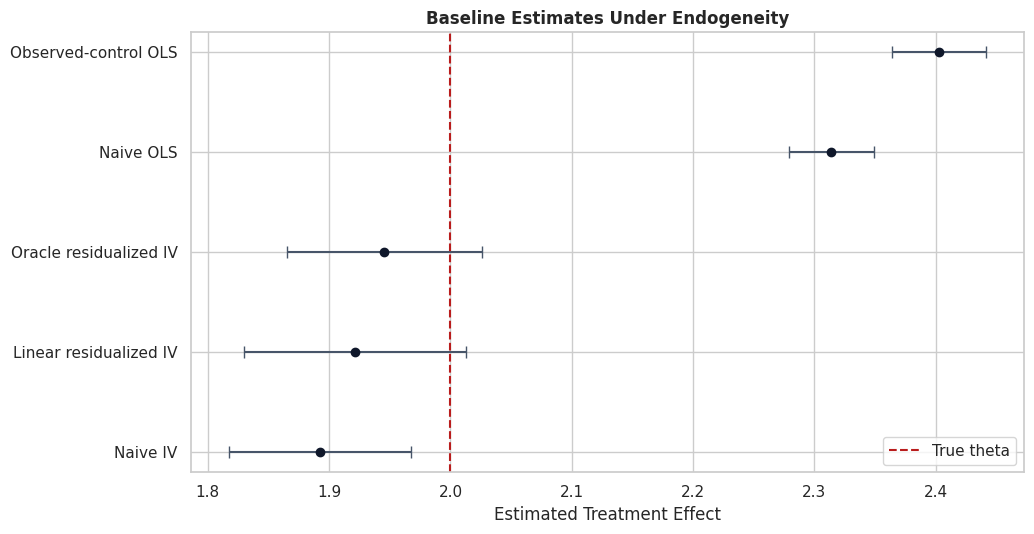

In [10]:
plot_baselines = baseline_estimates.copy()
plot_baselines = plot_baselines.sort_values("theta_hat")
plot_baselines["lower_error"] = plot_baselines["theta_hat"] - plot_baselines["ci_95_lower"]
plot_baselines["upper_error"] = plot_baselines["ci_95_upper"] - plot_baselines["theta_hat"]

fig, ax = plt.subplots(figsize=(10.5, 5.5))
y_pos = np.arange(len(plot_baselines))
ax.errorbar(
    x=plot_baselines["theta_hat"],
    y=y_pos,
    xerr=[plot_baselines["lower_error"], plot_baselines["upper_error"]],
    fmt="o",
    color="#0f172a",
    ecolor="#475569",
    capsize=4,
)
ax.axvline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.5, label="True theta")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_baselines["estimator"])
ax.set_xlabel("Estimated Treatment Effect")
ax.set_title("Baseline Estimates Under Endogeneity")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The visual contrast is the reason for using IV. Observed controls help, but they cannot remove a hidden common cause. The instrument changes which treatment variation identifies the slope.

#### First-Stage Relevance Screen

A relevant instrument must predict treatment after adjusting for controls. Here we use a linear residualized first-stage screen:

1. residualize treatment on `X`;
2. residualize instrument on `X`;
3. regress residualized treatment on residualized instrument.

This serves a different role than the only possible first-stage diagnostic. It gives an intuitive relevance check.

In [11]:
first_stage_table = pd.DataFrame(
    [
        first_stage_summary(d, z, "Raw first stage"),
        first_stage_summary(linear_d_resid, linear_z_resid, "Linear residualized first stage"),
        first_stage_summary(oracle_d_resid, oracle_z_resid, "Oracle residualized first stage"),
    ]
)
save_table(first_stage_table, "first_stage_relevance_screen")
display(first_stage_table)

,diagnostic,first_stage_slope,first_stage_r2,first_stage_f_stat,residual_corr_z_d
0,Raw first stage,0.827788,0.279944,971.175003,0.529097
1,Linear residualized first stage,0.796256,0.207512,654.100047,0.455535
2,Oracle residualized first stage,0.795393,0.206756,651.092278,0.454704


The residualized first stage is strong in this synthetic design. In applied IV work, weak first-stage evidence should make the estimate a warning sign rather than a final answer.

#### Residual First-Stage Plot

This figure shows the relationship between residualized instrument and residualized treatment after linear adjustment for `X`.

The slope is the first-stage relationship. If this cloud were almost flat, the instrument would provide little usable treatment variation.

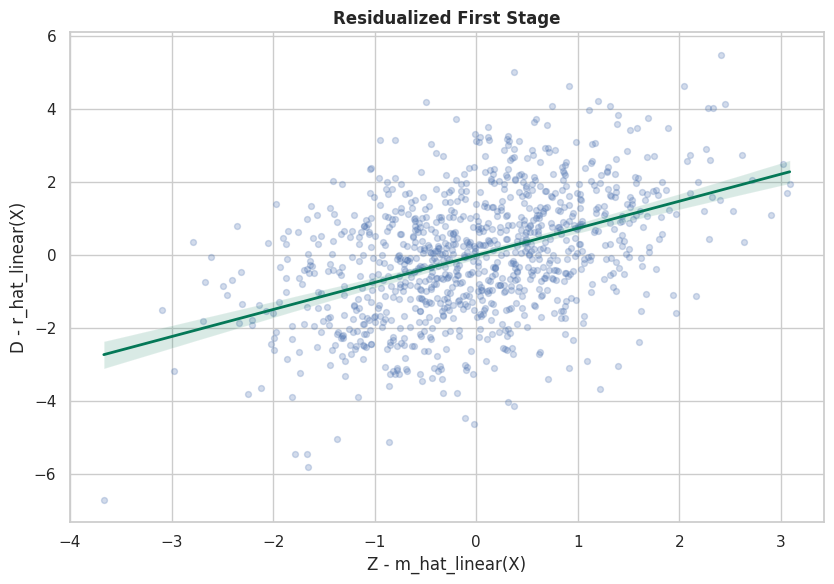

In [12]:
first_stage_plot_df = pd.DataFrame(
    {
        "residualized_instrument": linear_z_resid,
        "residualized_treatment": linear_d_resid,
    }
).sample(1_000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.regplot(
    data=first_stage_plot_df,
    x="residualized_instrument",
    y="residualized_treatment",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#047857", "linewidth": 2},
    ax=ax,
)
ax.set_title("Residualized First Stage")
ax.set_xlabel("Z - m_hat_linear(X)")
ax.set_ylabel("D - r_hat_linear(X)")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_residualized_first_stage.png", dpi=160, bbox_inches="tight")
plt.show()


A strong visible first stage does not prove the instrument is valid. It only supports the relevance part of the IV design.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


### Nuisance Learners for PLIV

For `DoubleMLPLIV` with the partialling-out score, the nuisance functions are:

- `ml_l`: learns `l0(X) = E[Y | X]`.
- `ml_m`: learns `m0(X) = E[Z | X]`.
- `ml_r`: learns `r0(X) = E[D | X]`.

This is a common source of confusion. In PLR, `ml_m` predicts treatment. In PLIV, `ml_m` predicts the instrument, and `ml_r` predicts treatment.

In [13]:
# Save the artifacts produced by the Nuisance Learners For PLIV section.
linear_nuisance = make_pipeline(
    StandardScaler(),
    LassoCV(cv=3, random_state=RANDOM_STATE, max_iter=5_000),
)

gradient_boosting_nuisance = HistGradientBoostingRegressor(
    max_iter=180,
    learning_rate=0.05,
    max_leaf_nodes=24,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

learner_catalog = pd.DataFrame(
    [
        {
            "learner_name": "Regularized linear nuisance",
            "use_case": "Transparent baseline; may underfit nonlinear nuisance functions.",
        },
        {
            "learner_name": "Histogram gradient boosting nuisance",
            "use_case": "Captures nonlinearities in outcome, treatment, and instrument nuisance functions.",
        },
    ]
)
save_table(learner_catalog, "learner_catalog")
display(learner_catalog)


,learner_name,use_case
0,Regularized linear nuisance,Transparent baseline; may underfit nonlinear nuisance functions.
1,Histogram gradient boosting nuisance,"Captures nonlinearities in outcome, treatment, and instrument nuisance functions."


The nuisance learners are not estimating the causal effect directly. They remove predictable parts of outcome, treatment, and instrument so that the final IV moment uses residualized variation.

#### Manual Cross-Fitted PLIV

Before using the package, we manually compute the partialling-out PLIV estimate with cross-fitted nuisance predictions.

The steps are:

1. Predict `Y` from `X` out of fold.
2. Predict `Z` from `X` out of fold.
3. Predict `D` from `X` out of fold.
4. Form residuals for outcome, instrument, and treatment.
5. Estimate the IV slope from residualized variables.

In [14]:
manual_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

manual_l_hat = cross_val_predict(clone(gradient_boosting_nuisance), X, y, cv=manual_cv, n_jobs=None)
manual_m_hat = cross_val_predict(clone(gradient_boosting_nuisance), X, z, cv=manual_cv, n_jobs=None)
manual_r_hat = cross_val_predict(clone(gradient_boosting_nuisance), X, d, cv=manual_cv, n_jobs=None)

manual_y_resid = y - manual_l_hat
manual_z_resid = z - manual_m_hat
manual_d_resid = d - manual_r_hat

manual_pliv_estimate = pd.DataFrame(
    [residual_iv_summary(manual_y_resid, manual_d_resid, manual_z_resid, "Manual cross-fitted PLIV")]
)
manual_pliv_estimate["true_theta"] = TRUE_THETA
manual_pliv_estimate["bias_vs_truth"] = manual_pliv_estimate["theta_hat"] - TRUE_THETA
save_table(manual_pliv_estimate, "manual_crossfit_pliv_estimate")
display(manual_pliv_estimate)


,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,moment_denominator,true_theta,bias_vs_truth
0,Manual cross-fitted PLIV,1.916462,0.047578,1.823209,2.009714,0.83993,2.0,-0.083538


This is the PLIV moment in plain Python. DoubleML automates this logic and adds inference, repeated sample splitting, score management, and a consistent model API.

### Manual Nuisance Quality

Because this is synthetic data, we can compare cross-fitted nuisance predictions with the true nuisance functions.

In real data, we cannot compute these columns. We would rely on out-of-fold predictive diagnostics, residual plots, first-stage checks, and the IV design argument.

In [15]:
# Save the artifacts produced by the Manual Nuisance Quality section.
manual_nuisance_quality = pd.DataFrame(
    [
        {
            "nuisance": "l(X) = E[Y | X]",
            "rmse_vs_true_nuisance": rmse(pliv_df["true_outcome_nuisance"], manual_l_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(pliv_df["true_outcome_nuisance"], manual_l_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(pliv_df["true_outcome_nuisance"], manual_l_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(y, manual_l_hat)),
        },
        {
            "nuisance": "m(X) = E[Z | X]",
            "rmse_vs_true_nuisance": rmse(pliv_df["true_instrument_nuisance"], manual_m_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(pliv_df["true_instrument_nuisance"], manual_m_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(pliv_df["true_instrument_nuisance"], manual_m_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(z, manual_m_hat)),
        },
        {
            "nuisance": "r(X) = E[D | X]",
            "rmse_vs_true_nuisance": rmse(pliv_df["true_treatment_nuisance"], manual_r_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(pliv_df["true_treatment_nuisance"], manual_r_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(pliv_df["true_treatment_nuisance"], manual_r_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(d, manual_r_hat)),
        },
    ]
)
save_table(manual_nuisance_quality, "manual_nuisance_quality")
display(manual_nuisance_quality)


,nuisance,rmse_vs_true_nuisance,mae_vs_true_nuisance,correlation_vs_true_nuisance,out_of_fold_r2_against_observed_target
0,l(X) = E[Y | X],1.455271,1.146746,0.832097,0.131435
1,m(X) = E[Z | X],0.348333,0.274338,0.917594,0.341723
2,r(X) = E[D | X],0.560213,0.442878,0.872111,0.188861


The nuisance functions are imperfect, especially because treatment and outcome contain hidden shocks. Orthogonal IV scoring is designed to reduce sensitivity to nuisance estimation error. Poor nuisance quality can still increase instability.

#### Manual Residual IV Plot

The next plot shows the residualized instrument-treatment relationship and the residualized instrument-outcome relationship.

PLIV uses the part of the instrument that remains after adjusting for controls. The treatment effect is identified by how that residualized instrument shifts residualized outcome through residualized treatment.

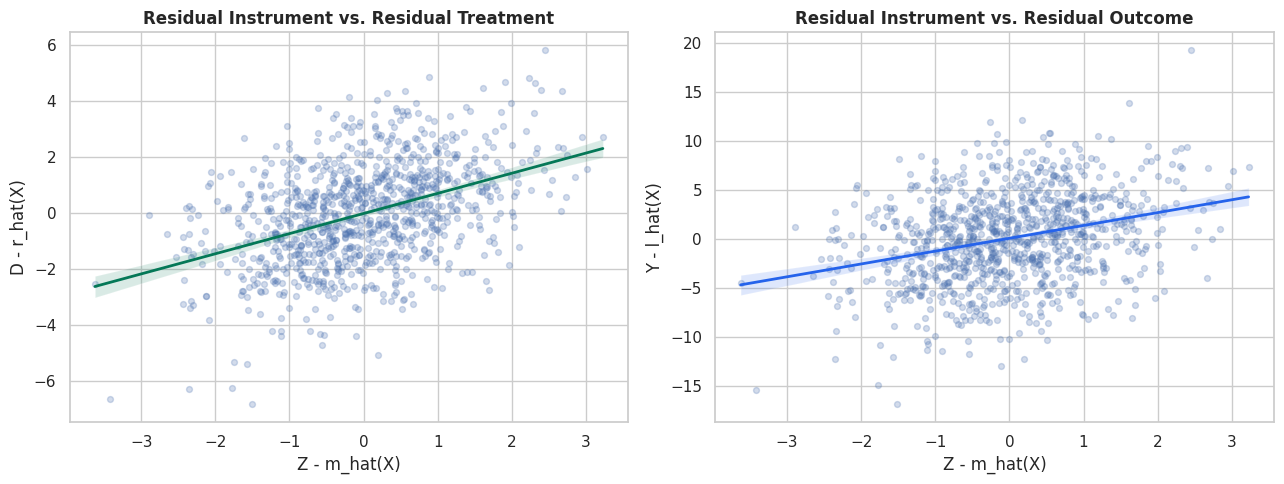

In [16]:
# Build and label the diagnostic visualization for the Manual Residual IV Plot section.
manual_resid_plot_df = pd.DataFrame(
    {
        "Z - m_hat(X)": manual_z_resid,
        "D - r_hat(X)": manual_d_resid,
        "Y - l_hat(X)": manual_y_resid,
    }
).sample(1_000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(
    data=manual_resid_plot_df,
    x="Z - m_hat(X)",
    y="D - r_hat(X)",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#047857", "linewidth": 2},
    ax=axes[0],
)
axes[0].set_title("Residual Instrument vs. Residual Treatment")

sns.regplot(
    data=manual_resid_plot_df,
    x="Z - m_hat(X)",
    y="Y - l_hat(X)",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#2563eb", "linewidth": 2},
    ax=axes[1],
)
axes[1].set_title("Residual Instrument vs. Residual Outcome")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_residual_iv_relationships.png", dpi=160, bbox_inches="tight")
plt.show()


The residualized instrument has a clear relationship with residualized treatment. That relevance is what makes the IV moment informative.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


#### Build the DoubleML Data Object

The `DoubleMLData` backend needs four role groups for PLIV:

- `y_col`: outcome.
- `d_cols`: treatment.
- `x_cols`: observed controls.
- `z_cols`: instrument.

The hidden teaching columns are excluded from the backend.

In [17]:
dml_data = DoubleMLData(
    pliv_df[["weekly_value", "exposure_intensity", "encouragement_score"] + feature_cols],
    y_col="weekly_value",
    d_cols="exposure_intensity",
    x_cols=feature_cols,
    z_cols="encouragement_score",
)

backend_summary = pd.DataFrame(
    [
        {"role": "outcome", "columns": dml_data.y_col},
        {"role": "treatment", "columns": ", ".join(dml_data.d_cols)},
        {"role": "instrument", "columns": ", ".join(dml_data.z_cols)},
        {"role": "controls", "columns": ", ".join(dml_data.x_cols)},
        {"role": "number_of_observations", "columns": str(dml_data.n_obs)},
    ]
)
save_table(backend_summary, "doublemldata_backend_summary")
display(backend_summary)


,role,columns
0,outcome,weekly_value
1,treatment,exposure_intensity
2,instrument,encouragement_score
3,controls,"engagement_score, need_intensity, content_fit, recent_activity, price_sensitivity, tenure_signal, novelty_appetite, seasonality_signal"
4,number_of_observations,2500


This data object is the executable version of the IV design. If the instrument were accidentally placed in `x_cols` instead of `z_cols`, the model would no longer represent the intended IV estimand.

#### Fit `DoubleMLPLIV`

We now fit `DoubleMLPLIV` with two nuisance specifications:

- regularized linear nuisances;
- gradient-boosted nuisances.

Both use the partialling-out score and five-fold cross-fitting.

In [18]:
# Fit or evaluate the model objects used in the Fit `DoubleMLPLIV` section.
pliv_models = {}

for model_name, learner in {
    "Linear nuisance PLIV": linear_nuisance,
    "Gradient boosting nuisance PLIV": gradient_boosting_nuisance,
}.items():
    model = DoubleMLPLIV(
        dml_data,
        ml_l=clone(learner),
        ml_m=clone(learner),
        ml_r=clone(learner),
        n_folds=5,
        n_rep=1,
        score="partialling out",
    )
    model.fit(store_predictions=True)
    pliv_models[model_name] = model
    print(f"Finished: {model_name}")

pliv_summary_rows = []
for model_name, model in pliv_models.items():
    summary = model.summary.reset_index().rename(columns={"index": "treatment"})
    row = summary.iloc[0].to_dict()
    pliv_summary_rows.append(
        {
            "estimator": model_name,
            "treatment": row["treatment"],
            "theta_hat": row["coef"],
            "std_error": row["std err"],
            "t_stat": row["t"],
            "p_value": row["P>|t|"],
            "ci_95_lower": row["2.5 %"],
            "ci_95_upper": row["97.5 %"],
            "true_theta": TRUE_THETA,
            "bias_vs_truth": row["coef"] - TRUE_THETA,
        }
    )

pliv_summary = pd.DataFrame(pliv_summary_rows)
save_table(pliv_summary, "doubleml_pliv_summary")
display(pliv_summary)


Finished: Linear nuisance PLIV


Finished: Gradient boosting nuisance PLIV


,estimator,treatment,theta_hat,std_error,t_stat,p_value,ci_95_lower,ci_95_upper,true_theta,bias_vs_truth
0,Linear nuisance PLIV,exposure_intensity,1.919675,0.046631,41.167162,0.0,1.828279,2.011070,2.0,-0.080325
1,Gradient boosting nuisance PLIV,exposure_intensity,1.929348,0.047482,40.632964,0.0,1.836284,2.022411,2.0,-0.070652


The PLIV estimates use residualized instrument variation rather than raw treatment variation. In this synthetic design, that should reduce the endogeneity bias that affected OLS.



#### Compare All Estimators

The comparison table combines OLS, manual IV, oracle IV, and DoubleML PLIV estimates.

The most important comparison is not package versus package. It is raw treatment variation versus instrument-induced treatment variation.

In [19]:
all_estimates = pd.concat(
    [
        baseline_estimates[["estimator", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "true_theta", "bias_vs_truth"]],
        manual_pliv_estimate[["estimator", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "true_theta", "bias_vs_truth"]],
        pliv_summary[["estimator", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "true_theta", "bias_vs_truth"]],
    ],
    ignore_index=True,
)
all_estimates["abs_bias_vs_truth"] = all_estimates["bias_vs_truth"].abs()
save_table(all_estimates, "all_estimator_comparison")
display(all_estimates.sort_values("abs_bias_vs_truth"))

,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,true_theta,bias_vs_truth,abs_bias_vs_truth
4,Oracle residualized IV,1.945621,0.040988,1.865285,2.025957,2.0,-0.054379,0.054379
7,Gradient boosting nuisance PLIV,1.929348,0.047482,1.836284,2.022411,2.0,-0.070652,0.070652
3,Linear residualized IV,1.921096,0.046626,1.829710,2.012483,2.0,-0.078904,0.078904
6,Linear nuisance PLIV,1.919675,0.046631,1.828279,2.011070,2.0,-0.080325,0.080325
5,Manual cross-fitted PLIV,1.916462,0.047578,1.823209,2.009714,2.0,-0.083538,0.083538
2,Naive IV,1.892202,0.038240,1.817252,1.967153,2.0,-0.107798,0.107798
0,Naive OLS,2.313825,0.017858,2.278824,2.348826,2.0,0.313825,0.313825
1,Observed-control OLS,2.402628,0.019802,2.363816,2.441439,2.0,0.402628,0.402628


The IV-based estimates are closer to the true effect than OLS because they avoid the hidden treatment-outcome path. The remaining differences are sampling noise and nuisance-model error.

#### Estimate Comparison Plot

This figure summarizes the estimator comparison. The dashed red line is the true effect in the simulation.

In real data, the goal would be to compare credible specifications and make assumptions explicit rather than to match a known truth.

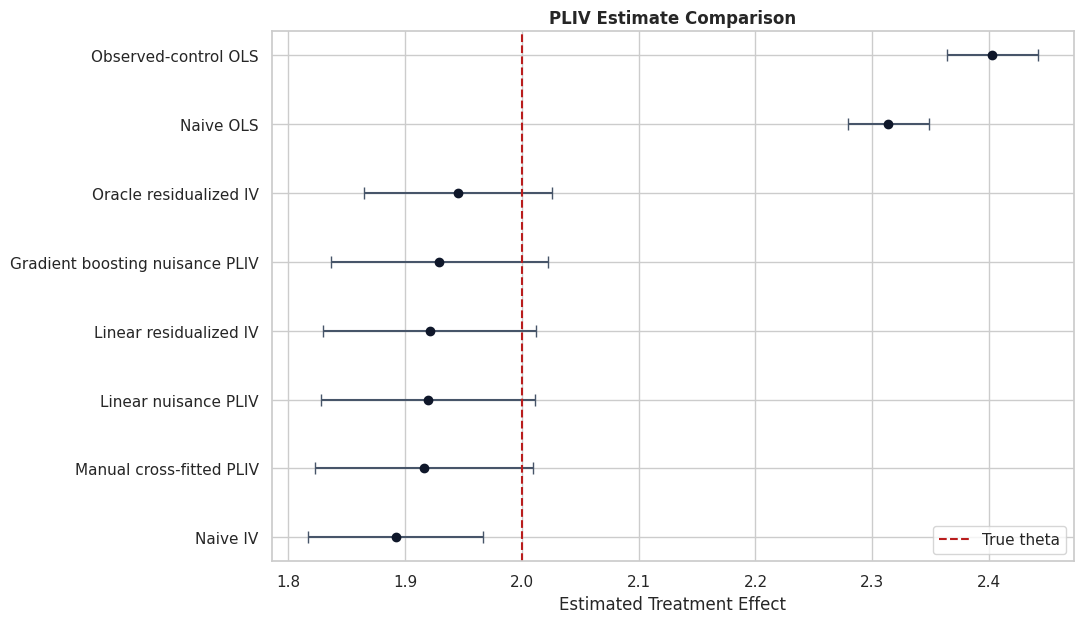

In [20]:
plot_estimates = all_estimates.copy().sort_values("theta_hat")
plot_estimates["lower_error"] = plot_estimates["theta_hat"] - plot_estimates["ci_95_lower"]
plot_estimates["upper_error"] = plot_estimates["ci_95_upper"] - plot_estimates["theta_hat"]

fig, ax = plt.subplots(figsize=(11, 6.4))
y_pos = np.arange(len(plot_estimates))
ax.errorbar(
    x=plot_estimates["theta_hat"],
    y=y_pos,
    xerr=[plot_estimates["lower_error"], plot_estimates["upper_error"]],
    fmt="o",
    color="#0f172a",
    ecolor="#475569",
    capsize=4,
)
ax.axvline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.5, label="True theta")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_estimates["estimator"])
ax.set_xlabel("Estimated Treatment Effect")
ax.set_title("PLIV Estimate Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pliv_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the cost of endogeneity visible. Observed-control OLS can look precise while still targeting the wrong variation.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




### Nuisance Losses

`evaluate_learners()` reports out-of-fold RMSE for the PLIV nuisance learners.

For `DoubleMLPLIV`, the keys are:

- `ml_l`: outcome nuisance.
- `ml_m`: instrument nuisance.
- `ml_r`: treatment nuisance.

These losses are diagnostics for the nuisance stage, not direct measures of instrument validity.

In [21]:
loss_tables = []
for model_name, model in pliv_models.items():
    loss_tables.append(learner_loss_table(model, model_name))

nuisance_losses = pd.concat(loss_tables, ignore_index=True)
save_table(nuisance_losses, "doubleml_nuisance_losses")
display(nuisance_losses)

,model,learner,mean_rmse,min_rmse,max_rmse
0,Linear nuisance PLIV,ml_l,4.606881,4.606881,4.606881
1,Linear nuisance PLIV,ml_m,1.021942,1.021942,1.021942
2,Linear nuisance PLIV,ml_r,1.781060,1.781060,1.781060
3,Gradient boosting nuisance PLIV,ml_l,4.676494,4.676494,4.676494
4,Gradient boosting nuisance PLIV,ml_m,1.043405,1.043405,1.043405
5,Gradient boosting nuisance PLIV,ml_r,1.828121,1.828121,1.828121


A lower nuisance RMSE can help, but IV credibility still depends on the instrument. Prediction quality cannot rescue an invalid instrument.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


#### Nuisance Predictions Against Truth

Because this is synthetic data, we can compare DoubleML's stored nuisance predictions against the true nuisance functions.

The code below focuses on the gradient-boosted PLIV fit.

In [22]:
# Save the artifacts produced by the Nuisance Predictions Against Truth section.
pliv_hgb = pliv_models["Gradient boosting nuisance PLIV"]
hgb_l_hat = prediction_vector(pliv_hgb, "ml_l")
hgb_m_hat = prediction_vector(pliv_hgb, "ml_m")
hgb_r_hat = prediction_vector(pliv_hgb, "ml_r")

hgb_nuisance_quality = pd.DataFrame(
    [
        {
            "nuisance": "ml_l outcome nuisance",
            "rmse_vs_true_nuisance": rmse(pliv_df["true_outcome_nuisance"], hgb_l_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(pliv_df["true_outcome_nuisance"], hgb_l_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(pliv_df["true_outcome_nuisance"], hgb_l_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(y, hgb_l_hat)),
        },
        {
            "nuisance": "ml_m instrument nuisance",
            "rmse_vs_true_nuisance": rmse(pliv_df["true_instrument_nuisance"], hgb_m_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(pliv_df["true_instrument_nuisance"], hgb_m_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(pliv_df["true_instrument_nuisance"], hgb_m_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(z, hgb_m_hat)),
        },
        {
            "nuisance": "ml_r treatment nuisance",
            "rmse_vs_true_nuisance": rmse(pliv_df["true_treatment_nuisance"], hgb_r_hat),
            "mae_vs_true_nuisance": float(mean_absolute_error(pliv_df["true_treatment_nuisance"], hgb_r_hat)),
            "correlation_vs_true_nuisance": float(np.corrcoef(pliv_df["true_treatment_nuisance"], hgb_r_hat)[0, 1]),
            "out_of_fold_r2_against_observed_target": float(r2_score(d, hgb_r_hat)),
        },
    ]
)
save_table(hgb_nuisance_quality, "hgb_nuisance_quality_against_truth")
display(hgb_nuisance_quality)


,nuisance,rmse_vs_true_nuisance,mae_vs_true_nuisance,correlation_vs_true_nuisance,out_of_fold_r2_against_observed_target
0,ml_l outcome nuisance,1.462238,1.142557,0.832793,0.130069
1,ml_m instrument nuisance,0.346904,0.273325,0.919466,0.350731
2,ml_r treatment nuisance,0.564845,0.439416,0.872767,0.185742


The instrument nuisance is easier to predict than the treatment nuisance because treatment contains the hidden demand shock. This mirrors real IV settings where treatment can be hard to predict fully from observed controls.



#### Visual Nuisance Diagnostics

This figure compares predicted nuisance functions to the true nuisance functions. The middle panel is especially useful because it reinforces that `ml_m` predicts the instrument in PLIV.

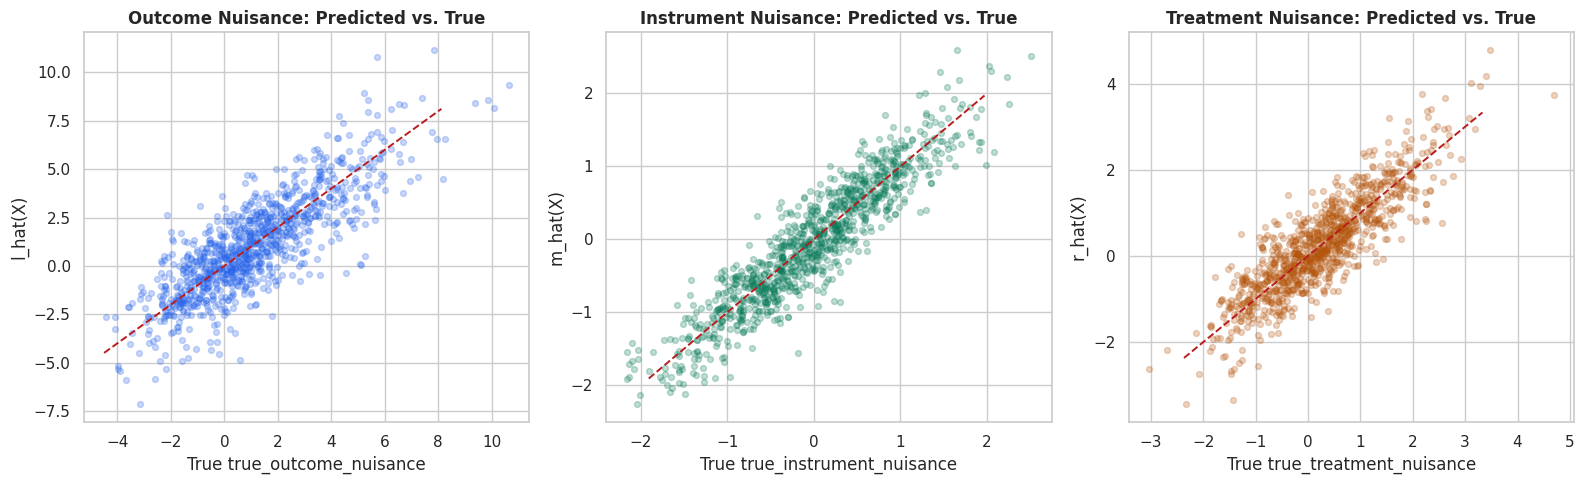

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sample_idx = pliv_df.sample(1_000, random_state=RANDOM_STATE).index

panels = [
    ("true_outcome_nuisance", hgb_l_hat, "Outcome Nuisance", "l_hat(X)", "#2563eb"),
    ("true_instrument_nuisance", hgb_m_hat, "Instrument Nuisance", "m_hat(X)", "#047857"),
    ("true_treatment_nuisance", hgb_r_hat, "Treatment Nuisance", "r_hat(X)", "#b45309"),
]

for ax, (truth_col, pred, title, ylabel, color) in zip(axes, panels):
    ax.scatter(pliv_df.loc[sample_idx, truth_col], pred[sample_idx], alpha=0.25, s=18, color=color)
    lower = min(pliv_df[truth_col].quantile(0.01), np.quantile(pred, 0.01))
    upper = max(pliv_df[truth_col].quantile(0.99), np.quantile(pred, 0.99))
    ax.plot([lower, upper], [lower, upper], color="#b91c1c", linestyle="--", linewidth=1.4)
    ax.set_title(f"{title}: Predicted vs. True")
    ax.set_xlabel(f"True {truth_col}")
    ax.set_ylabel(ylabel)

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nuisance_prediction_quality.png", dpi=160, bbox_inches="tight")
plt.show()


The plots show useful but imperfect nuisance recovery. That is the normal DML setting: flexible learners help estimate nuisance structure, while orthogonal scores reduce first-order sensitivity to nuisance errors.

#### Residual Diagnostics from DoubleML

The residualized instrument and treatment are central to PLIV. If the residualized instrument has little relationship with residualized treatment, the IV estimate will be unstable.

The code below summarizes the residual distributions and the residualized first stage from the gradient-boosted DoubleML fit.

In [24]:
# Fit or evaluate the model objects used in the Residual Diagnostics From DoubleML section.
dml_y_resid = y - hgb_l_hat
dml_z_resid = z - hgb_m_hat
dml_d_resid = d - hgb_r_hat

residual_summary = pd.DataFrame(
    [
        {
            "residual": "Y - l_hat(X)",
            "mean": float(np.mean(dml_y_resid)),
            "std": float(np.std(dml_y_resid, ddof=1)),
            "p05": float(np.quantile(dml_y_resid, 0.05)),
            "median": float(np.median(dml_y_resid)),
            "p95": float(np.quantile(dml_y_resid, 0.95)),
        },
        {
            "residual": "Z - m_hat(X)",
            "mean": float(np.mean(dml_z_resid)),
            "std": float(np.std(dml_z_resid, ddof=1)),
            "p05": float(np.quantile(dml_z_resid, 0.05)),
            "median": float(np.median(dml_z_resid)),
            "p95": float(np.quantile(dml_z_resid, 0.95)),
        },
        {
            "residual": "D - r_hat(X)",
            "mean": float(np.mean(dml_d_resid)),
            "std": float(np.std(dml_d_resid, ddof=1)),
            "p05": float(np.quantile(dml_d_resid, 0.05)),
            "median": float(np.median(dml_d_resid)),
            "p95": float(np.quantile(dml_d_resid, 0.95)),
        },
    ]
)
save_table(residual_summary, "dml_residual_summary")
display(residual_summary)

dml_first_stage = pd.DataFrame([first_stage_summary(dml_d_resid, dml_z_resid, "DoubleML HGB residualized first stage")])
save_table(dml_first_stage, "dml_residualized_first_stage")
display(dml_first_stage)


,residual,mean,std,p05,median,p95
0,Y - l_hat(X),0.009943,4.677419,-7.704090,0.151405,7.506718
1,Z - m_hat(X),0.003835,1.043607,-1.722708,0.021895,1.719139
2,D - r_hat(X),-0.001313,1.828487,-3.053185,0.047404,3.015696


,diagnostic,first_stage_slope,first_stage_r2,first_stage_f_stat,residual_corr_z_d
0,DoubleML HGB residualized first stage,0.758127,0.18723,575.438361,0.4327


The residualized first stage remains strong. This supports the relevance condition after flexible adjustment for observed controls.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


#### Residual Distribution Plot

This plot shows the residualized outcome, instrument, and treatment distributions from the DoubleML fit.

The instrument residual should have meaningful spread. The treatment residual should also have meaningful spread. If either collapses, the IV moment becomes fragile.

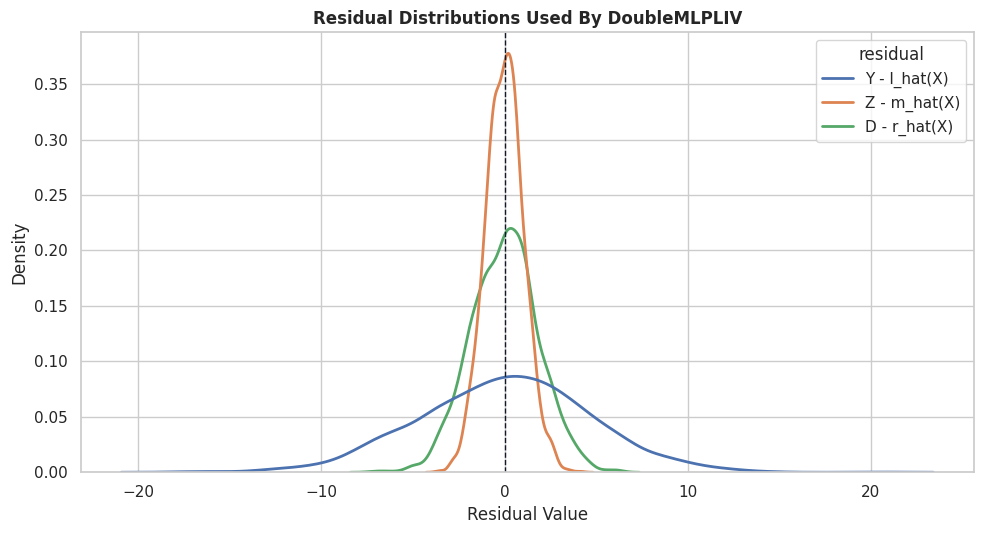

In [25]:
resid_long = pd.DataFrame(
    {
        "Y - l_hat(X)": dml_y_resid,
        "Z - m_hat(X)": dml_z_resid,
        "D - r_hat(X)": dml_d_resid,
    }
).melt(var_name="residual", value_name="value")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.kdeplot(data=resid_long, x="value", hue="residual", fill=False, common_norm=False, linewidth=2, ax=ax)
ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
ax.set_title("Residual Distributions Used By DoubleMLPLIV")
ax.set_xlabel("Residual Value")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_residual_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


The residual distributions look well spread in this synthetic setting. That gives the IV score enough variation to estimate the slope.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


#### Orthogonal Score Contributions

DoubleML stores the score contributions `psi`. At the fitted estimate, the average score should be close to zero.

Large tails can signal influential observations or a noisy denominator in the IV moment.

,mean,std,p01,p05,median,p95,p99
0,-1.520561e-16,1.959875,-5.560101,-3.12013,0.001594,2.94634,5.564406


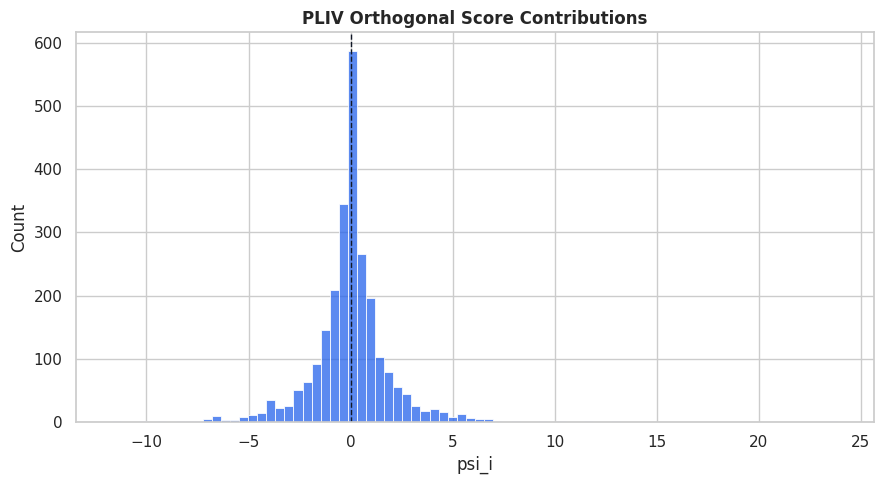

In [26]:
# Build and label the diagnostic visualization for the Orthogonal Score Contributions section.
psi_values = np.asarray(pliv_hgb.psi)[:, 0, 0]
psi_summary = pd.DataFrame(
    [
        {
            "mean": float(np.mean(psi_values)),
            "std": float(np.std(psi_values, ddof=1)),
            "p01": float(np.quantile(psi_values, 0.01)),
            "p05": float(np.quantile(psi_values, 0.05)),
            "median": float(np.median(psi_values)),
            "p95": float(np.quantile(psi_values, 0.95)),
            "p99": float(np.quantile(psi_values, 0.99)),
        }
    ]
)
save_table(psi_summary, "orthogonal_score_summary")
display(psi_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(psi_values, bins=80, color="#2563eb", alpha=0.75, ax=ax)
ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
ax.set_title("PLIV Orthogonal Score Contributions")
ax.set_xlabel("psi_i")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_orthogonal_score_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The score is centered near zero, as expected at the fitted estimate. The tail behavior is another reminder that IV uncertainty can be sensitive to residual instrument strength.

#### Partialling-Out Score vs. IV-Type Score

`DoubleMLPLIV` supports both `partialling out` and `IV-type` scores. The default partialling-out score estimates `l`, `m`, and `r`. The IV-type score also uses `ml_g`, a nuisance learner for a transformed outcome equation.

The code below fits an IV-type score as a specification comparison and shows how to run the supported score variants side by side.

In [27]:
# Fit or evaluate the model objects used in the Partialling-Out Score vs. IV-Type Score section.
iv_type_learner = HistGradientBoostingRegressor(
    max_iter=140,
    learning_rate=0.06,
    max_leaf_nodes=20,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

pliv_iv_type = DoubleMLPLIV(
    dml_data,
    ml_l=clone(iv_type_learner),
    ml_m=clone(iv_type_learner),
    ml_r=clone(iv_type_learner),
    ml_g=clone(iv_type_learner),
    n_folds=5,
    n_rep=1,
    score="IV-type",
)
pliv_iv_type.fit(store_predictions=True)

score_variant_summary = pd.concat(
    [
        pliv_hgb.summary.reset_index().rename(columns={"index": "treatment"}).assign(score="partialling out"),
        pliv_iv_type.summary.reset_index().rename(columns={"index": "treatment"}).assign(score="IV-type"),
    ],
    ignore_index=True,
)
score_variant_summary["true_theta"] = TRUE_THETA
score_variant_summary["bias_vs_truth"] = score_variant_summary["coef"] - TRUE_THETA
save_table(score_variant_summary, "score_variant_summary")
display(score_variant_summary)


,treatment,coef,std err,t,P>|t|,2.5 %,97.5 %,score,true_theta,bias_vs_truth
0,exposure_intensity,1.929348,0.047482,40.632964,0.0,1.836284,2.022411,partialling out,2.0,-0.070652
1,exposure_intensity,1.937792,0.044586,43.461477,0.0,1.850404,2.025180,IV-type,2.0,-0.062208


The score variants are close in this synthetic example. In applied work, large differences across reasonable scores or learners would deserve investigation before writing a conclusion.

#### Bootstrap Confidence Interval

DoubleML can compute bootstrap-based confidence intervals. Bootstrap tools are especially useful when there are multiple parameters or joint inference needs.

Here we run a moderate bootstrap for the main gradient-boosted PLIV fit.

In [28]:
pliv_hgb.bootstrap(method="normal", n_rep_boot=500)
bootstrap_ci = pliv_hgb.confint(joint=False, level=0.95).reset_index().rename(columns={"index": "treatment"})
bootstrap_ci["estimator"] = "Gradient boosting nuisance PLIV bootstrap"
save_table(bootstrap_ci, "hgb_bootstrap_confidence_interval")
display(bootstrap_ci)

,treatment,2.5 %,97.5 %,estimator
0,exposure_intensity,1.836284,2.022411,Gradient boosting nuisance PLIV bootstrap


The bootstrap interval quantifies sampling uncertainty under the fitted IV design. It does not validate the exclusion restriction or remove weak-instrument concerns.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




#### Repeated Sample Splitting

Cross-fitted estimates can move slightly with different fold splits. Repeated sample splitting checks whether the result is stable across split draws.

The code below uses a lighter learner so the repeated-split check remains practical.

In [29]:
# Fit or evaluate the model objects used in the Repeated Sample Splitting section.
repeated_split_learner = HistGradientBoostingRegressor(
    max_iter=110,
    learning_rate=0.06,
    max_leaf_nodes=18,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

pliv_repeated = DoubleMLPLIV(
    dml_data,
    ml_l=clone(repeated_split_learner),
    ml_m=clone(repeated_split_learner),
    ml_r=clone(repeated_split_learner),
    n_folds=5,
    n_rep=5,
    score="partialling out",
)
pliv_repeated.fit(store_predictions=False)

split_stability = pd.DataFrame(
    {
        "repetition": np.arange(1, pliv_repeated.all_coef.shape[1] + 1),
        "theta_hat": pliv_repeated.all_coef[0],
        "std_error": pliv_repeated.all_se[0],
    }
)
split_stability["true_theta"] = TRUE_THETA
split_stability["bias_vs_truth"] = split_stability["theta_hat"] - TRUE_THETA
save_table(split_stability, "repeated_sample_split_stability")
display(split_stability)


,repetition,theta_hat,std_error,true_theta,bias_vs_truth
0,1,1.908868,0.047831,2.0,-0.091132
1,2,1.898199,0.046047,2.0,-0.101801
2,3,1.910093,0.044864,2.0,-0.089907
3,4,1.922756,0.046830,2.0,-0.077244
4,5,1.921245,0.046435,2.0,-0.078755


Small split-to-split movement is expected. Large movement would suggest a fragile first stage, unstable nuisance models, or insufficient sample size.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->




#### Split Stability Plot

The next figure shows the repeated-split estimates. The dashed red line marks the true synthetic effect.

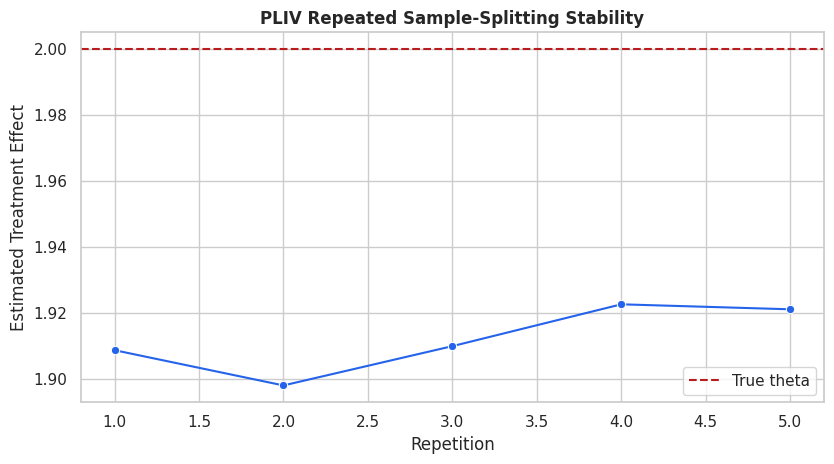

In [30]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.lineplot(data=split_stability, x="repetition", y="theta_hat", marker="o", color="#2563eb", ax=ax)
ax.axhline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.5, label="True theta")
ax.set_title("PLIV Repeated Sample-Splitting Stability")
ax.set_xlabel("Repetition")
ax.set_ylabel("Estimated Treatment Effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_repeated_split_stability.png", dpi=160, bbox_inches="tight")
plt.show()

The estimate is reasonably stable across fold repetitions here. This is a numerical stability check, not a substitute for instrument validity.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


#### Weak-Instrument Stress Test

A weak instrument has little residual relationship with treatment. When the first-stage denominator becomes small, IV estimates can become noisy and unreliable.

This synthetic stress test changes only the first-stage strength and uses the true nuisance functions to isolate the weak-instrument issue from nuisance-model error.

In [31]:
# Save the artifacts produced by the Weak-Instrument Stress Test section.
weak_rows = []
for strength in [0.10, 0.25, 0.50, 0.85, 1.20]:
    d_strength = (
        strength * encouragement_score
        + true_treatment_x_signal
        + HIDDEN_CONFOUNDING_STRENGTH * latent_demand_shock
        + treatment_noise
    )
    r_strength = strength * true_instrument_nuisance + true_treatment_x_signal
    y_strength = TRUE_THETA * d_strength + true_structural_g + HIDDEN_OUTCOME_STRENGTH * latent_demand_shock + outcome_noise
    l_strength = TRUE_THETA * r_strength + true_structural_g

    y_resid_strength = y_strength - l_strength
    d_resid_strength = d_strength - r_strength
    z_resid_strength = encouragement_score - true_instrument_nuisance

    estimate = residual_iv_summary(
        y_resid_strength,
        d_resid_strength,
        z_resid_strength,
        f"oracle residual IV, strength={strength:.2f}",
    )
    fs = first_stage_summary(d_resid_strength, z_resid_strength, f"strength={strength:.2f}")
    weak_rows.append(
        {
            "first_stage_strength": strength,
            "theta_hat": estimate["theta_hat"],
            "std_error": estimate["std_error"],
            "ci_95_lower": estimate["ci_95_lower"],
            "ci_95_upper": estimate["ci_95_upper"],
            "moment_denominator": estimate["moment_denominator"],
            "first_stage_f_stat": fs["first_stage_f_stat"],
            "residual_corr_z_d": fs["residual_corr_z_d"],
        }
    )

weak_instrument_table = pd.DataFrame(weak_rows)
weak_instrument_table["true_theta"] = TRUE_THETA
weak_instrument_table["bias_vs_truth"] = weak_instrument_table["theta_hat"] - TRUE_THETA
save_table(weak_instrument_table, "weak_instrument_stress_test")
display(weak_instrument_table)


,first_stage_strength,theta_hat,std_error,ci_95_lower,ci_95_upper,moment_denominator,first_stage_f_stat,residual_corr_z_d,true_theta,bias_vs_truth
0,0.10,1.049002,1.199758,-1.302524,3.400529,0.044639,2.120628,0.029124,2.0,-0.950998
1,0.25,1.778719,0.184506,1.417086,2.140351,0.191844,39.291486,0.124441,2.0,-0.221281
2,0.50,1.902898,0.075084,1.755735,2.050062,0.437186,204.157885,0.274870,2.0,-0.097102
3,0.85,1.945621,0.040988,1.865285,2.025957,0.780665,651.092278,0.454704,2.0,-0.054379
4,1.20,1.962237,0.028186,1.906993,2.017480,1.124143,1350.168344,0.592334,2.0,-0.037763


As the first stage gets weaker, the residual instrument-treatment relationship shrinks and the standard error grows. This is why first-stage diagnostics belong in every IV report.



#### Weak-Instrument Plot

The next figure shows how first-stage strength changes uncertainty. The point estimates may move around because finite samples are noisy, but the uncertainty pattern is the main lesson.

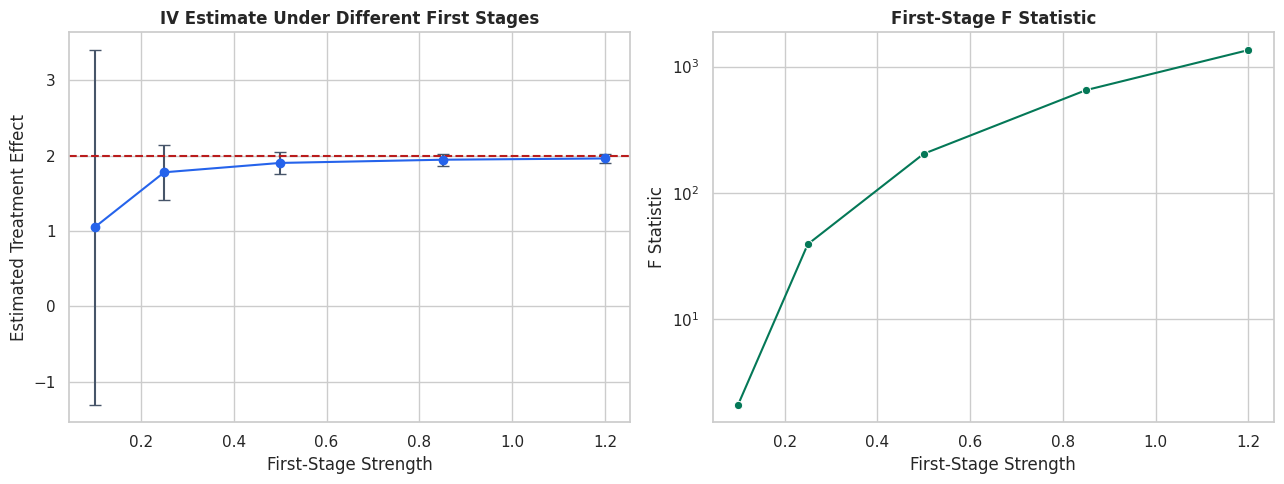

In [32]:
# Build and label the diagnostic visualization for the Weak-Instrument Plot section.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(
    x=weak_instrument_table["first_stage_strength"],
    y=weak_instrument_table["theta_hat"],
    yerr=[
        weak_instrument_table["theta_hat"] - weak_instrument_table["ci_95_lower"],
        weak_instrument_table["ci_95_upper"] - weak_instrument_table["theta_hat"],
    ],
    fmt="o-",
    color="#2563eb",
    ecolor="#475569",
    capsize=4,
)
axes[0].axhline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.5)
axes[0].set_title("IV Estimate Under Different First Stages")
axes[0].set_xlabel("First-Stage Strength")
axes[0].set_ylabel("Estimated Treatment Effect")

sns.lineplot(
    data=weak_instrument_table,
    x="first_stage_strength",
    y="first_stage_f_stat",
    marker="o",
    color="#047857",
    ax=axes[1],
)
axes[1].set_title("First-Stage F Statistic")
axes[1].set_xlabel("First-Stage Strength")
axes[1].set_ylabel("F Statistic")
axes[1].set_yscale("log")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_weak_instrument_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()


The weak-instrument problem is not a software problem. It is a design problem. Better learners do not create instrument relevance when the instrument barely moves treatment.



#### Exclusion-Violation Stress Test

Now we keep the first stage fixed but add a direct effect from the residual instrument to the outcome. This breaks the exclusion restriction.

The calculation again uses true nuisance functions so we can isolate the design failure. If the instrument directly affects the outcome, IV estimates can be biased even when the first stage is strong.

In [33]:
# Save the artifacts produced by the Exclusion-Violation Stress Test section.
exclusion_rows = []
z_residual_oracle = encouragement_score - true_instrument_nuisance

for direct_effect in [0.00, 0.10, 0.25, 0.50]:
    y_invalid = weekly_value + direct_effect * z_residual_oracle
    l_invalid = true_outcome_nuisance
    estimate = residual_iv_summary(
        y_invalid - l_invalid,
        oracle_d_resid,
        oracle_z_resid,
        f"direct Z effect={direct_effect:.2f}",
    )
    exclusion_rows.append(
        {
            "direct_instrument_effect": direct_effect,
            "theta_hat": estimate["theta_hat"],
            "std_error": estimate["std_error"],
            "ci_95_lower": estimate["ci_95_lower"],
            "ci_95_upper": estimate["ci_95_upper"],
            "true_theta": TRUE_THETA,
            "bias_vs_truth": estimate["theta_hat"] - TRUE_THETA,
        }
    )

exclusion_violation_table = pd.DataFrame(exclusion_rows)
save_table(exclusion_violation_table, "exclusion_violation_stress_test")
display(exclusion_violation_table)


,direct_instrument_effect,theta_hat,std_error,ci_95_lower,ci_95_upper,true_theta,bias_vs_truth
0,0.00,1.945621,0.040988,1.865285,2.025957,2.0,-0.054379
1,0.10,2.071331,0.038126,1.996605,2.146057,2.0,0.071331
2,0.25,2.259894,0.034715,2.191853,2.327935,2.0,0.259894
3,0.50,2.574167,0.032161,2.511131,2.637204,2.0,0.574167


The estimate moves as the exclusion violation grows. This is the hard part of IV: the most important assumption cannot usually be verified by a first-stage plot.



#### Exclusion-Violation Plot

The next figure visualizes how a direct instrument-outcome path changes the estimated treatment effect.

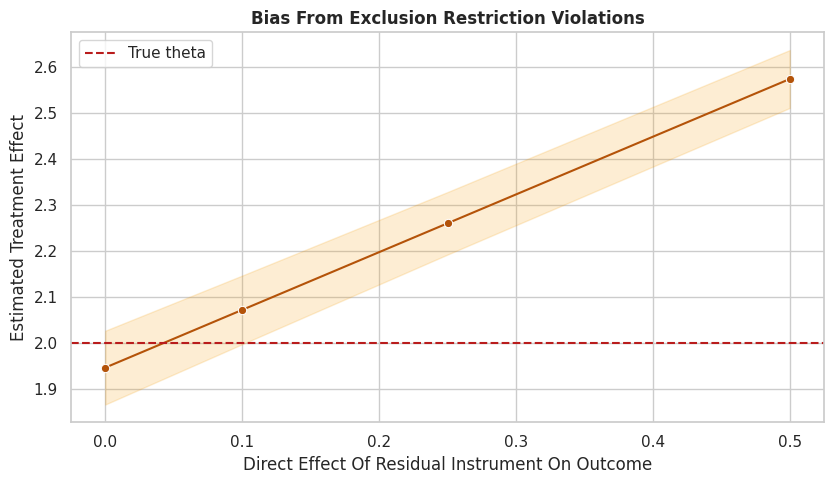

In [34]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(
    data=exclusion_violation_table,
    x="direct_instrument_effect",
    y="theta_hat",
    marker="o",
    color="#b45309",
    ax=ax,
)
ax.fill_between(
    exclusion_violation_table["direct_instrument_effect"],
    exclusion_violation_table["ci_95_lower"],
    exclusion_violation_table["ci_95_upper"],
    color="#f59e0b",
    alpha=0.18,
)
ax.axhline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.5, label="True theta")
ax.set_title("Bias From Exclusion Restriction Violations")
ax.set_xlabel("Direct Effect Of Residual Instrument On Outcome")
ax.set_ylabel("Estimated Treatment Effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_exclusion_violation_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()


This is why IV writeups need a design story. A strong first stage plus a violated exclusion restriction can still produce a misleading result.

#### When PLIV is the Right or Wrong Tool

PLIV is useful when:

- treatment is continuous;
- unobserved confounding is plausible after observed-control adjustment;
- a credible instrument shifts treatment;
- the target can be summarized as a constant linear treatment effect.

PLIV is not the right tool when:

- the treatment is binary and compliance is central, where an interactive IV model may be more natural;
- no credible instrument exists;
- the instrument barely moves treatment;
- the instrument directly affects the outcome;
- the treatment effect is too heterogeneous for a constant-slope summary to be meaningful.




## Reporting and Takeaways

### Reporting Checklist

A useful PLIV report should make the instrument argument as visible as the estimate.

This checklist turns the notebook into a reusable applied workflow.

| item | status |
| --- | --- |
| Causal question | Estimate effect of exposure_intensity on weekly_value using instrument-induced variation. |
| Treatment type | Continuous treatment; PLIV constant-slope estimand is appropriate for the teaching design. |
| Instrument role | encouragement_score assigned through z_cols, not included as an ordinary control. |
| Relevance | Residualized first-stage diagnostics reported. |
| Exclusion | Valid by construction in synthetic data; requires design evidence in real data. |
| Conditional independence | Valid by construction after X in synthetic data; requires design evidence in real data. |
| Nuisance learners | Compared regularized linear and gradient-boosted nuisances. |
| Cross-fitting | Used five folds and manually demonstrated cross-fitted residualized IV. |
| Uncertainty | Reported standard errors, confidence intervals, and a bootstrap interval. |
| Stability | Checked repeated sample splitting. |
| Cautions | Included weak-instrument and exclusion-violation stress tests. |


The checklist separates estimable diagnostics from assumptions that need a design argument. That separation is the heart of honest IV reporting.

The implication is design-specific: relevance can be diagnosed with data, while validity still depends on whether the instrument affects the outcome only through treatment.
<!-- result-implication-expanded -->


### Report Template

The next cell writes a short markdown report template using the main gradient-boosted PLIV estimate.

This is not meant to be copied blindly. It is a structure for explaining the estimate, the instrument, the first stage, and the limitations.

In [35]:
main_row = pliv_summary.loc[pliv_summary["estimator"] == "Gradient boosting nuisance PLIV"].iloc[0]
first_stage_row = dml_first_stage.iloc[0]

report_text = f"""
# PLIV Effect Estimate Report Template

## Causal Question
Estimate the effect of `exposure_intensity` on `weekly_value` using `encouragement_score` as an instrument.

## Design Logic
The concern is that unobserved factors may affect both treatment and outcome. The instrument is intended to shift treatment while affecting the outcome only through treatment after adjusting for observed controls.

## Estimator
The main estimator is `DoubleMLPLIV` with the partialling-out score, five-fold cross-fitting, and histogram gradient-boosting nuisance learners.

## Main Estimate
- Estimated effect: {main_row['theta_hat']:.4f}
- Standard error: {main_row['std_error']:.4f}
- 95 percent confidence interval: [{main_row['ci_95_lower']:.4f}, {main_row['ci_95_upper']:.4f}]

## First Stage
- Residualized first-stage slope: {first_stage_row['first_stage_slope']:.4f}
- Residualized first-stage F statistic: {first_stage_row['first_stage_f_stat']:.2f}
- Residual instrument-treatment correlation: {first_stage_row['residual_corr_z_d']:.4f}

## Diagnostics Included
- OLS, naive IV, residualized IV, oracle IV, and DoubleML PLIV comparisons.
- First-stage relevance screen.
- Manual cross-fitted PLIV calculation.
- Nuisance learner RMSE checks.
- Residual distribution and score contribution checks.
- Score variant comparison.
- Bootstrap confidence interval.
- Repeated sample-splitting stability.
- Weak-instrument and exclusion-violation stress tests.

## Required Assumptions
The estimate relies on instrument relevance, exclusion, and conditional independence after controls. Relevance is screened in the data. Exclusion and conditional independence require design evidence and cannot be established by DoubleML alone.
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_pliv_report_template.md"
report_path.write_text(report_text)
print(report_text)


# PLIV Effect Estimate Report Template

## Causal Question
Estimate the effect of `exposure_intensity` on `weekly_value` using `encouragement_score` as an instrument.

## Design Logic
The concern is that unobserved factors may affect both treatment and outcome. The instrument is intended to shift treatment while affecting the outcome only through treatment after adjusting for observed controls.

## Estimator
The main estimator is `DoubleMLPLIV` with the partialling-out score, five-fold cross-fitting, and histogram gradient-boosting nuisance learners.

## Main Estimate
- Estimated effect: 1.9293
- Standard error: 0.0475
- 95 percent confidence interval: [1.8363, 2.0224]

## First Stage
- Residualized first-stage slope: 0.7581
- Residualized first-stage F statistic: 575.44
- Residual instrument-treatment correlation: 0.4327

## Diagnostics Included
- OLS, naive IV, residualized IV, oracle IV, and DoubleML PLIV comparisons.
- First-stage relevance screen.
- Manual cross-fitted PLIV calcul

The report template keeps the instrument assumptions next to the numeric estimate. That is essential for IV work: the model output and the instrument story must travel together.

The PLIV notebook is complete. The next natural topic is the interactive regression model for binary treatments, where propensity scores and potential-outcome nuisance functions become central.